# NLP Pipeline Notebook
Chạy các cell theo thứ tự từ trên xuống để:
1. Đọc / tạo `cleaned_dataset.csv` từ các file raw
2. Chuẩn hoá văn bản → `cleaned_dataset_fixed.csv`
3. Sinh báo cáo JSON + biểu đồ `pipeline_report.*`

**Yêu cầu:** `outputs/cleaned_dataset.csv` _hoặc_ `yt_comments.csv` + `voz_threads_comments.csv` ở thư mục gốc dự án.

## Cell 1 – Imports & Logging

In [1]:
from __future__ import annotations

import html as html_module
import json
import logging
import re
import unicodedata
from collections import Counter
from pathlib import Path
from typing import Dict, List, Set, Tuple

import matplotlib.pyplot as plt
import pandas as pd

log = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
print("Imports OK")

Imports OK


## Cell 2 – Regex patterns & constants

In [2]:
# ──────────────────── Regex patterns ────────────────────
HTML_TAG  = re.compile(r"<[^>]+>")
URL_PAT   = re.compile(r"https?://\S+|www\.\S+")
MENTION   = re.compile(r"@[\w_]+")
HASHTAG   = re.compile(r"#[\w_]+")
TIMESTAMP = re.compile(r"\b\d{1,2}:\d{2}\b")
REPEATED  = re.compile(r"(.)\1{2,}")
MULTI_SP  = re.compile(r"\s+")
VI_CHAR_PAT = re.compile(
    r"[àáảãạăắặẳẵâấầẩẫậđèéẻẽẹêếềểễệìíỉĩịòóỏõọôốồổỗộơớờởỡợùúủũụưứừửữựỳýỷỹỵ"
    r"ÀÁẢÃẠĂẮẶẲẴÂẤẦẨẪẬĐÈÉẺẼẸÊẾỀỂỄỆÌÍỈĨỊÒÓỎÕỌÔỐỒỔỖỘƠỚỜỞỠỢÙÚỦŨỤƯỨỪỬỮỰỲÝỶỸỴ]"
)
UNICODE_KEEP = re.compile(
    r"[^\u0041-\u007A\u00C0-\u024F\u1E00-\u1EFF\u0300-\u036F"
    r"\u0110\u0111\u0128\u0129\u01A0\u01A1\u01AF\u01B0"
    r"0-9\s\.!\?…]",
    re.UNICODE,
)

# ──────────────────── Word sets ────────────────────
EN_STOPWORDS: Set[str] = {
    "the", "is", "are", "was", "were", "have", "has", "had",
    "this", "that", "these", "those", "you", "your", "with",
    "from", "they", "them", "their", "what", "which", "who",
    "will", "would", "could", "should", "can", "not", "don",
    "fish", "why", "how", "when", "where", "then", "than",
    "all", "for", "and", "but", "or", "so", "if", "it",
}

VI_ONLY_MAP: Dict[str, str] = {
    "t": "tôi", "a": "anh", "e": "em", "m": "mình",
    "k": "không", "r": "rồi", "j": "gì", "v": "vậy", "h": "giờ",
}

SAFE_MAP: Dict[str, str] = {
    "ko": "không", "kg": "không", "khg": "không",
    "hok": "không", "hong": "không", "hông": "không", "hem": "không", "hk": "không",
    "dc": "được", "đc": "được", "dk": "được", "đk": "được",
    "bik": "biết", "bít": "biết",
    "mik": "mình", "mk": "mình",
    "thui": "thôi", "thoy": "thôi",
    "cx": "cũng", "cug": "cũng",
    "chx": "chưa",
    "z": "vậy", "zậy": "vậy",
    "đr": "rồi", "rùi": "rồi",
    "ntn": "như thế nào",
    "mn": "mọi người", "mng": "mọi người",
    "ae": "anh em",
    "yt": "youtube", "youtobe": "youtube",
    "vl": "rất", "vcl": "rất",
    "bt": "bình thường",
    "nma": "nhưng mà",
    "đag": "đang", "đangg": "đang",
    "okie": "ổn", "oke": "ổn", "okela": "ổn",
    "iu": "yêu",
    "ny": "người yêu",
    "nv": "nhân viên",
    "cmt": "bình luận", "ib": "nhắn tin",
}

STOPWORD_WHITELIST: Set[str] = {
    "không", "có", "được", "đã", "đang", "rất", "và", "là",
    "rồi", "ra", "lên", "về", "từ", "gì", "ai", "hay", "hoặc",
    "mà", "thì", "nên", "với", "do", "bị", "cho", "khi", "vì", "nếu",
}

NOISE_TOKENS: Set[str] = {
    "href", "http", "https", "www", "com", "amp", "quot", "br", "nbsp", "html", "css",
}
PARTICLE_TOKENS: Set[str] = {"ạ", "à", "ơ", "ơi", "nha", "nhé", "nhỉ", "hả", "ha", "ư", "nè"}
IMPORTANT_SHORT: Set[str] = {
    "ở", "đi", "về", "lên", "ra", "vô", "vào", "đã", "sẽ", "là", "và", "có",
    "cho", "từ", "với", "do", "bị", "hay", "rất", "quá", "mà", "thì", "nên", "hoặc", "gì", "ai",
}

_TOKENIZER: str | None = None
print("Constants & patterns OK")

Constants & patterns OK


## Cell 3 – Utility functions (language detection, noise removal)

In [3]:
def detect_language(text: str) -> str:
    if not text or len(text.strip()) < 3:
        return "vi"
    has_vi = bool(VI_CHAR_PAT.search(text))
    words_lower = text.lower().split()
    en_word_count = sum(1 for w in words_lower if w in EN_STOPWORDS)
    if has_vi and en_word_count < 3:
        return "vi"
    if not has_vi and en_word_count >= 2:
        return "en"
    if has_vi and en_word_count >= 3:
        return "mixed"
    return "vi"


def extract_from_html(text: str) -> str:
    if "<" not in text:
        return text
    try:
        from bs4 import BeautifulSoup  # type: ignore
        return BeautifulSoup(text, "html.parser").get_text(" ", strip=True)
    except ImportError:
        return HTML_TAG.sub(" ", text)


def remove_noise(text: str) -> str:
    text = extract_from_html(text)
    text = URL_PAT.sub(" ", text)
    text = TIMESTAMP.sub(" ", text)
    text = MENTION.sub(" ", text)
    text = HASHTAG.sub(" ", text)
    text = REPEATED.sub(r"\1\1", text)
    text = UNICODE_KEEP.sub(" ", text)
    text = MULTI_SP.sub(" ", text).strip()
    return text


def split_sentences(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?…])\s+", text)
    return [p.strip() for p in parts if p.strip()]


print("Utility functions (lang detection, noise removal) OK")

Utility functions (lang detection, noise removal) OK


## Cell 4 – Normalisation functions

In [4]:
def load_normalization_map(path: Path) -> Tuple[Dict[str, str], Dict[str, str]]:
    dangerous_short = {"t", "k", "r", "j", "v", "h", "g", "m", "n"}
    safe: Dict[str, str] = {**SAFE_MAP}
    vi_only: Dict[str, str] = {**VI_ONLY_MAP}
    if not path.exists():
        log.warning("normalization_map.json not found – using built-in defaults.")
        return safe, vi_only
    raw = json.loads(path.read_text(encoding="utf-8"))
    for k, v in raw.items():
        k_nfc = unicodedata.normalize("NFC", str(k).strip().lower())
        v_nfc = unicodedata.normalize("NFC", str(v).strip().lower())
        if not v_nfc:
            continue
        if k_nfc in dangerous_short:
            vi_only[k_nfc] = v_nfc
        else:
            safe.setdefault(k_nfc, v_nfc)
    return safe, vi_only


def load_stopwords(path: Path) -> Set[str]:
    if not path.exists():
        log.warning("vietnamese_stopwords.txt not found – using empty set.")
        return set()
    raw = {l.strip().lower() for l in path.read_text(encoding="utf-8").splitlines() if l.strip()}
    return raw - STOPWORD_WHITELIST


def apply_phrase_norm(text: str) -> str:
    replacements = [
        (re.compile(r"\bvẫn\s+đề\b"), "vấn đề"),
        (re.compile(r"\bko\s+sao\b"), "không sao"),
        (re.compile(r"\bko\s+vấn\s+đề\b"), "không vấn đề"),
        (re.compile(r"\byou\s*tube\b", re.I), "youtube"),
        (re.compile(r"\ba\s+chua\b"), "anh chưa"),
        (re.compile(r"\ba\s+sang\b"), "anh sang"),
        (re.compile(r"\be\s+sang\b"), "em sang"),
        (re.compile(r"\bnha\s+a\b"), "nha anh"),
        (re.compile(r"\bvideo\s+a\b"), "video anh"),
        (re.compile(r"\bae\s+oi\b"), "anh em ơi"),
    ]
    for pat, rep in replacements:
        text = pat.sub(rep, text)
    return text


def normalize_chat_pronouns(text: str) -> str:
    replacements = [
        (re.compile(r"\ba\b"), "anh"),
        (re.compile(r"\be\b"), "em"),
        (re.compile(r"\bm\b"), "mình"),
        (re.compile(r"\bt\b"), "tôi"),
    ]
    out = text
    for pat, rep in replacements:
        out = pat.sub(rep, out)
    return out


def apply_word_norm(text: str, safe_map: Dict[str, str], vi_only_map: Dict[str, str], lang: str) -> str:
    result = []
    for w in text.split():
        key = w.strip()
        mapped = safe_map.get(key, w)
        if lang in ("vi", "mixed"):
            mapped = vi_only_map.get(key, mapped)
        result.append(mapped)
    return " ".join(result)


print("Normalisation functions OK")

Normalisation functions OK


## Cell 5 – Tokenizer & token cleaning

In [5]:
def _init_tokenizer() -> str:
    global _TOKENIZER
    if _TOKENIZER:
        return _TOKENIZER
    try:
        import underthesea  # type: ignore  # noqa: F401
        _TOKENIZER = "underthesea"
    except ImportError:
        try:
            from pyvi import ViTokenizer  # type: ignore  # noqa: F401
            _TOKENIZER = "pyvi"
        except ImportError:
            _TOKENIZER = "basic"
            log.warning("Không tìm thấy underthesea / pyvi → dùng basic split()")
    log.info("Tokenizer: %s", _TOKENIZER)
    return _TOKENIZER


def tokenize_vi(text: str) -> List[str]:
    tok = _init_tokenizer()
    all_tokens: List[str] = []
    for sent in split_sentences(text):
        if tok == "underthesea":
            from underthesea import word_tokenize  # type: ignore
            all_tokens.extend(word_tokenize(sent, format="text").split())
        elif tok == "pyvi":
            from pyvi import ViTokenizer  # type: ignore
            all_tokens.extend(ViTokenizer.tokenize(sent).split())
        else:
            all_tokens.extend(sent.split())
    return all_tokens


def tokenize_en(text: str) -> List[str]:
    text = re.sub(r"'s\b", "", text)
    text = re.sub(r"n't\b", "nt", text)
    text = re.sub(r"'re\b|'ve\b|'ll\b|'d\b", "", text)
    return text.split()


def clean_token(tok: str, lang: str) -> str:
    tok = tok.strip().lower()
    if not tok:
        return ""
    if tok in IMPORTANT_SHORT:
        return tok
    if tok in NOISE_TOKENS or tok in PARTICLE_TOKENS or tok.isdigit():
        return ""
    tok = tok.strip("_")
    tok = REPEATED.sub(r"\1\1", tok)
    for suffix in ("_nha", "_nhé", "_nhe", "_ha", "_hả", "_ạ", "_ơi"):
        if tok.endswith(suffix) and len(tok) > len(suffix) + 1:
            tok = tok[: -len(suffix)]
    if len(tok) <= 1 and tok.isascii():
        return ""
    if lang == "en" and tok in {"a", "i", "s", "nt", "dont", "im", "its", "thats"}:
        return ""
    if tok in {"sang_năm", "sang_nam"}:
        return "sang"
    return tok


print("Tokenizer & clean_token OK – tokenizer:", _init_tokenizer())

2026-03-24 21:41:24,923 [INFO] Tokenizer: underthesea


Tokenizer & clean_token OK – tokenizer: underthesea


## Cell 6 – Core preprocessing & pipeline functions

In [6]:
def preprocess_text(
    text: str,
    safe_map: Dict[str, str],
    vi_only_map: Dict[str, str],
    stopwords: Set[str],
    remove_stopwords: bool = False,
) -> Tuple[str, List[str], str]:
    if not isinstance(text, str):
        text = "" if pd.isna(text) else str(text)
    if not text.strip():
        return "", [], "vi"
    text = unicodedata.normalize("NFC", html_module.unescape(text)).lower().strip()
    lang = detect_language(text)
    text = remove_noise(text)
    if lang in ("vi", "mixed"):
        text = apply_phrase_norm(text)
        text = normalize_chat_pronouns(text)
    text = apply_word_norm(text, safe_map, vi_only_map, lang)
    tokens = tokenize_en(text) if lang == "en" else tokenize_vi(text)
    tokens = [clean_token(t, lang) for t in tokens]
    tokens = [t for t in tokens if t]
    if remove_stopwords:
        tokens = [t for t in tokens if t not in stopwords]
    return " ".join(tokens), tokens, lang


def fix_cleaned_dataset(
    input_csv: Path,
    output_csv: Path,
    safe_map: Dict[str, str],
    vi_only_map: Dict[str, str],
    stopwords: Set[str],
    remove_stopwords: bool = False,
) -> pd.DataFrame:
    df = pd.read_csv(input_csv, encoding="utf-8-sig")
    results = [
        preprocess_text(t, safe_map, vi_only_map, stopwords, remove_stopwords=remove_stopwords)
        for t in df["raw_text"].tolist()
    ]
    df["clean_text"] = [r[0] for r in results]
    df["tokens"]     = [r[1] for r in results]
    df["token_len"]  = df["tokens"].apply(len)
    df["lang"]       = [r[2] for r in results]
    df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)
    output_csv.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(output_csv, index=False, encoding="utf-8-sig")
    return df


print("Core pipeline functions OK")

Core pipeline functions OK


## Cell 7 – Report & analysis functions

In [7]:
def analyze_underscore_tokens(df: pd.DataFrame) -> Dict[str, object]:
    counter: Counter = Counter()
    for toks in df["tokens"]:
        if isinstance(toks, list):
            for t in toks:
                if "_" in str(t):
                    counter[t] += 1
    return {
        "total_underscore_types": len(counter),
        "total_underscore_occurrences": sum(counter.values()),
        "top_30": counter.most_common(30),
    }


def generate_report(df: pd.DataFrame, output_dir: Path) -> None:
    output_dir.mkdir(parents=True, exist_ok=True)
    report = {
        "total_rows": len(df),
        "source_distribution": df["source"].value_counts().to_dict(),
        "lang_distribution":   df["lang"].value_counts().to_dict(),
        "avg_token_len":       float(df["token_len"].mean()),
        "underscore_analysis": analyze_underscore_tokens(df),
    }
    (output_dir / "pipeline_report.json").write_text(
        json.dumps(report, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    df["source"].value_counts().plot(kind="bar", ax=axes[0], color=["#2E86AB", "#F18F01"])
    axes[0].set_title("Phân bố theo nguồn")
    axes[0].tick_params(axis="x", rotation=0)

    df["lang"].value_counts().plot(kind="bar", ax=axes[1], color=["#3B7A57", "#E84855", "#F4A261"])
    axes[1].set_title("Phân bố ngôn ngữ")
    axes[1].tick_params(axis="x", rotation=0)

    df["token_len"].plot(kind="hist", bins=40, ax=axes[2], color="#6A4C93")
    axes[2].set_title("Phân bố số token")
    plt.tight_layout()
    plt.savefig(output_dir / "pipeline_report.png", dpi=150)
    plt.show()
    plt.close()
    print("Report saved:", output_dir / "pipeline_report.json")


print("Report & analysis functions OK")

Report & analysis functions OK


## Cell 8 – Bootstrap: tạo `cleaned_dataset.csv` nếu chưa có

In [8]:
def bootstrap_input_if_missing(project_root: Path, input_csv: Path) -> None:
    """Tạo cleaned_dataset.csv từ yt_comments.csv + voz_threads_comments.csv nếu chưa có."""
    if input_csv.exists():
        print(f"Input dataset đã tồn tại: {input_csv} ({input_csv.stat().st_size // 1024} KB)")
        return
    yt_csv  = project_root / "yt_comments.csv"
    voz_csv = project_root / "voz_threads_comments.csv"
    missing = [str(p) for p in (yt_csv, voz_csv) if not p.exists()]
    if missing:
        raise FileNotFoundError(
            f"Thiếu cleaned_dataset.csv và không tìm thấy: {', '.join(missing)}\n"
            f"Hãy đặt yt_comments.csv và voz_threads_comments.csv vào: {project_root}"
        )
    yt_df  = pd.read_csv(yt_csv)
    voz_df = pd.read_csv(voz_csv)
    # Chấp nhận nhiều tên cột khác nhau cho raw text
    def get_text_col(df: pd.DataFrame) -> pd.Series:
        for col in ("text", "comment", "content", "body"):
            if col in df.columns:
                return df[col].astype(str)
        return df.iloc[:, 0].astype(str)  # fallback: cột đầu tiên

    yt_boot  = pd.DataFrame({"source": "youtube", "raw_text": get_text_col(yt_df)})
    voz_boot = pd.DataFrame({"source": "voz",     "raw_text": get_text_col(voz_df)})
    boot_df  = pd.concat([yt_boot, voz_boot], ignore_index=True)
    boot_df  = boot_df.dropna(subset=["raw_text"])
    boot_df  = boot_df[boot_df["raw_text"].str.strip() != ""]
    input_csv.parent.mkdir(parents=True, exist_ok=True)
    boot_df.to_csv(input_csv, index=False, encoding="utf-8-sig")
    print(f"Đã tạo bootstrap input: {input_csv} ({len(boot_df)} rows)")


print("bootstrap_input_if_missing OK")

bootstrap_input_if_missing OK


## Cell 9 – Cấu hình đường dẫn & load resources

In [9]:
# ── Tự tìm project root dù notebook chạy từ bất kỳ thư mục nào ──
def find_project_root() -> Path:
    """Đi lên tối đa 4 cấp cho đến khi tìm thấy folder 'outputs' hoặc 'resources'."""
    candidate = Path.cwd()
    for _ in range(4):
        if (candidate / "outputs").exists() or (candidate / "resources").exists():
            return candidate
        candidate = candidate.parent
    # fallback: thư mục CWD gốc
    return Path.cwd()


project_root   = find_project_root()
output_dir     = project_root / "outputs"
input_csv      = output_dir / "cleaned_dataset.csv"
norm_map       = project_root / "resources" / "normalization_map.json"
stopwords_path = project_root / "resources" / "vietnamese_stopwords.txt"

print(f"project_root   : {project_root}")
print(f"input_csv      : {input_csv}  (exists={input_csv.exists()})")
print(f"norm_map       : {norm_map}  (exists={norm_map.exists()})")
print(f"stopwords_path : {stopwords_path}  (exists={stopwords_path.exists()})")

safe_map, vi_only_map = load_normalization_map(norm_map)
stopwords = load_stopwords(stopwords_path)
print(f"\nSafe map entries  : {len(safe_map)}")
print(f"Vi-only map entries: {len(vi_only_map)}")
print(f"Stopwords loaded  : {len(stopwords)}")

project_root   : c:\VIET\2-2026\NLP
input_csv      : c:\VIET\2-2026\NLP\outputs\cleaned_dataset.csv  (exists=True)
norm_map       : c:\VIET\2-2026\NLP\resources\normalization_map.json  (exists=True)
stopwords_path : c:\VIET\2-2026\NLP\resources\vietnamese_stopwords.txt  (exists=True)

Safe map entries  : 159
Vi-only map entries: 10
Stopwords loaded  : 62


## Cell 10 – Chạy pipeline & sinh báo cáo

Input dataset đã tồn tại: c:\VIET\2-2026\NLP\outputs\cleaned_dataset.csv (546 KB)


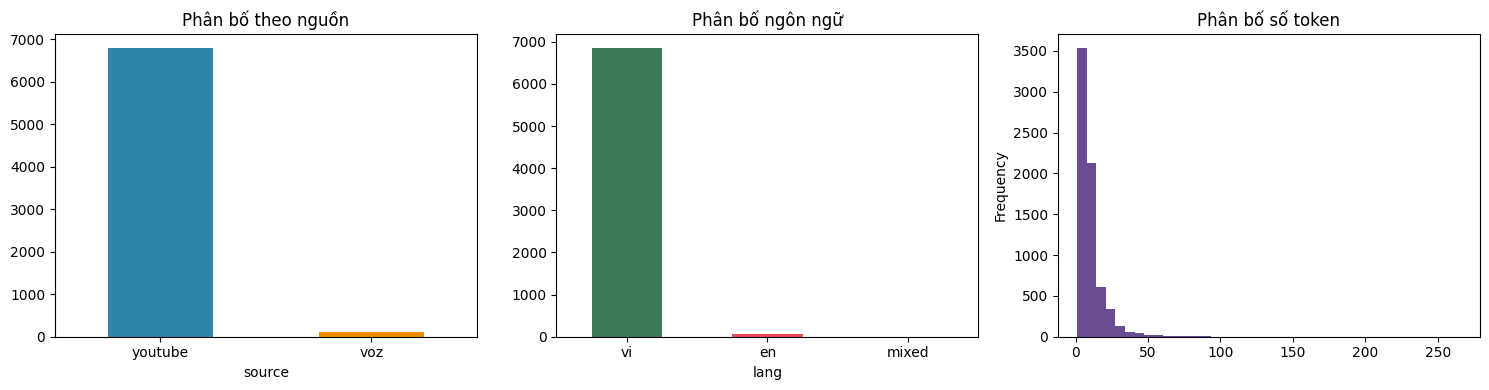

Report saved: c:\VIET\2-2026\NLP\outputs\pipeline_report.json

✅ Hoàn thành – 6,905 rows


,source,raw_text,clean_text,lang
0,youtube,"cam on nha, Thoi khong coi kich cua Tran Than...",cam on thôi không coi kich cua tran thanh_dong...,vi
1,youtube,"Vlog rì viu đồ ăn mà chỉ ngắm Hari Won thoi, 2...",vlog rì_viu đồ_ăn mà chỉ ngắm hari won thôi vợ...,vi
2,youtube,Anh sắm con poket 3 của Dji á quay vlog là êm ...,anh sắm con poket của dji á quay vlog là êm nó...,vi
3,youtube,"<a href=""https://www.youtube.com/watch?v=ZeXK3...",dạ xin cảm_ơn chị mà bà chị trả_lời thanks_tua...,vi
4,youtube,Anh tran thanh gia dinh em rat thich xem,anh tran thanh_gia_dinh em rat thich xem,vi
5,youtube,"<a href=""https://www.youtube.com/watch?v=ZeXK3...",choãii nước mínn,vi
6,youtube,z đó mà nhìn miệng 2 vợ chồng anh chị là em ch...,vậy đó mà nhìn miệng vợ_chồng anh_chị là em ch...,vi
7,youtube,thích xem ghê,thích xem ghê,vi
8,youtube,coi review food street thôi mà cười quá cười :))),coi review food street thôi mà cười quá cười,vi
9,youtube,"<a href=""https://www.youtube.com/watch?v=ZeXK3...",bà hari,vi


In [10]:
# Bootstrap nếu cleaned_dataset.csv chưa tồn tại
bootstrap_input_if_missing(project_root, input_csv)

# Xử lý & lưu cleaned_dataset_fixed.csv
df = fix_cleaned_dataset(
    input_csv=input_csv,
    output_csv=output_dir / "cleaned_dataset_fixed.csv",
    safe_map=safe_map,
    vi_only_map=vi_only_map,
    stopwords=stopwords,
    remove_stopwords=False,
)

# Sinh báo cáo JSON + biểu đồ
generate_report(df, output_dir)

print(f"\n✅ Hoàn thành – {len(df):,} rows")
display(df[["source", "raw_text", "clean_text", "lang"]].head(10))